# YZM304 Proje 2 - Hibrit CNN + Makine Öğrenmesi Modeli

Bu notebook, ödevin hibrit model kısmını karşılamak için hazırlanmıştır.

Amaç:
- Tam bir CNN mimarisini özellik çıkarıcı olarak kullanmak
- Eğitim ve test kümeleri için özellik vektörlerini üretmek
- Bu özellikleri `.npy` dosyalarına kaydetmek
- Özellikler üzerinde klasik bir makine öğrenmesi modeli eğitmek
- Hibrit modeli, aynı veri seti üzerinde çalışan tam CNN modeli ile karşılaştırmak


## Ödev Gereksinimleri ile Eşleştirme

Bu notebook aşağıdaki ödev maddelerini karşılar:
- Bir CNN mimarisinin özellik çıkarım mekanizmasının kullanılması
- Özellik ve etiket kümelerinin `.npy` uzantılı dosyalara kaydedilmesi
- Oluşan veri kümelerinin boyut ve uzunluklarının açık biçimde yazdırılması
- Klasik bir makine öğrenmesi modeli ile eğitim ve test yapılması
- Hibrit modelin tam CNN ile karşılaştırılması

Bu karşılaştırmada, tam CNN modeli olarak `ImprovedCNN` kullanılmıştır. Böylece ödevde belirtilen "ilk 3 modelden biri ile karşılaştırma" şartı sağlanır ve ayrıca 5. bir tam CNN modeli yazmak zorunlu olmaz.


In [1]:
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')


Kullanılan cihaz: cuda


## Proje Klasörleri ve Hiperparametreler

Bu notebook, birinci notebook ile aynı klasör yapısını kullanır. Eğer birinci notebook'tan `ImprovedCNN` ağırlıkları varsa onları yükler. Yoksa aynı notebook içinde modeli yeniden eğitir.


In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
ARTIFACTS_DIR = PROJECT_DIR / 'proje2_cnn_odevi'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
MODELS_DIR = ARTIFACTS_DIR / 'models'
FEATURES_DIR = ARTIFACTS_DIR / 'features'

for directory in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, FEATURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
VALIDATION_RATIO = 0.1
NUM_WORKERS = 0
PIN_MEMORY = device.type == 'cuda'

CLASS_NAMES = [str(i) for i in range(10)]
CHECKPOINT_PATH = MODELS_DIR / 'model_2_-_improved_cnn_best.pth'

print('Checkpoint yolu:', CHECKPOINT_PATH)


Checkpoint yolu: d:\okul\3. sınıf yzm\Deep Learning\lab 2\proje2_cnn_odevi\proje2_cnn_odevi\models\model_2_-_improved_cnn_best.pth


## Veri Seti

Aynı veri seti ve benzer ön işleme adımları kullanılır. Bu projede veri seti olarak SVHN seçildiği için hem hibrit model hem de tam CNN modeli sokak görüntülerinden alınan rakam sınıfları üzerinde karşılaştırılır.


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)),
])

full_train_dataset = datasets.SVHN(root=DATA_DIR, split='train', download=True, transform=transform)
test_dataset = datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=transform)

val_size = int(len(full_train_dataset) * VALIDATION_RATIO)
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

feature_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
feature_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Eğitim örneği     : {len(train_dataset)}')
print(f'Doğrulama örneği  : {len(val_dataset)}')
print(f'Test örneği       : {len(test_dataset)}')


100%|██████████| 182M/182M [02:54<00:00, 1.04MB/s] 
100%|██████████| 64.3M/64.3M [00:45<00:00, 1.40MB/s]


Eğitim örneği     : 65932
Doğrulama örneği  : 7325
Test örneği       : 26032


## Özellik Çıkarıcı Olarak Kullanılacak CNN

Aşağıda, birinci notebook'taki `ImprovedCNN` mimarisinin aynı yapısı tekrar tanımlanır. Ek olarak `extract_features` isimli bir metod yazılır. Böylece sınıflandırıcıdan önceki yoğun özellik vektörleri elde edilebilir.

Bu yapı hibrit modelin temelidir:
- CNN: derin özellikleri öğrenir
- SVM: bu özellikler üzerinde sınıflandırma yapar


In [4]:
class ImprovedCNNFeatureExtractor(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.flatten = nn.Flatten()
        self.embedding = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def extract_features(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.embedding(x)
        return x

    def forward(self, x):
        x = self.extract_features(x)
        x = self.classifier(x)
        return x

model = ImprovedCNNFeatureExtractor().to(device)
print(model)


ImprovedCNNFeatureExtractor(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (embedding): Sequential(
    (0): Dropout(p=0.3, inplace=False

## Eğitim Fonksiyonları

Önce tam CNN modeli eğitilir veya varsa kaydedilmiş ağırlıklar yüklenir. Sonra bu modelin ara katmanından özellik çıkarılır.


In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device, collect_predictions=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_samples += batch_size

            if collect_predictions:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    result = {
        'loss': total_loss / total_samples,
        'accuracy': total_correct / total_samples,
    }

    if collect_predictions:
        result['predictions'] = np.array(all_preds)
        result['labels'] = np.array(all_labels)

    return result


def train_or_load_cnn(model, checkpoint_path, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()

    if checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print('Kaydedilmiş ağırlıklar yüklendi.')
        history = None
        return model, history

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])

        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), checkpoint_path)
    print('En iyi CNN ağırlıkları kaydedildi.')
    return model, history


In [6]:
model, cnn_history = train_or_load_cnn(model, CHECKPOINT_PATH, epochs=EPOCHS, lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
cnn_test_metrics = evaluate(model, test_loader, criterion, device, collect_predictions=True)

print(f"Tam CNN test doğruluğu: {cnn_test_metrics['accuracy']:.4f}")


Epoch 01/10 | train_loss=0.8939 train_acc=0.7096 | val_loss=0.4930 val_acc=0.8516
Epoch 02/10 | train_loss=0.4897 train_acc=0.8508 | val_loss=0.3695 val_acc=0.8891
Epoch 03/10 | train_loss=0.4158 train_acc=0.8756 | val_loss=0.3348 val_acc=0.9018
Epoch 04/10 | train_loss=0.3789 train_acc=0.8866 | val_loss=0.3189 val_acc=0.9063
Epoch 05/10 | train_loss=0.3467 train_acc=0.8964 | val_loss=0.2914 val_acc=0.9158
Epoch 06/10 | train_loss=0.3196 train_acc=0.9040 | val_loss=0.2861 val_acc=0.9149
Epoch 07/10 | train_loss=0.3035 train_acc=0.9094 | val_loss=0.2760 val_acc=0.9197
Epoch 08/10 | train_loss=0.2850 train_acc=0.9148 | val_loss=0.2719 val_acc=0.9222
Epoch 09/10 | train_loss=0.2700 train_acc=0.9195 | val_loss=0.2715 val_acc=0.9201
Epoch 10/10 | train_loss=0.2608 train_acc=0.9226 | val_loss=0.2484 val_acc=0.9309
En iyi CNN ağırlıkları kaydedildi.
Tam CNN test doğruluğu: 0.9268


## Özellik Çıkarma ve `.npy` Dosyaları

Bu adım ödevin en kritik bölümüdür. CNN'in sınıflandırıcıya gitmeden önce ürettiği 256 boyutlu özellik vektörleri alınır ve disk üzerine kaydedilir.

Kaydedilen dosyalar:
- `X_train.npy`
- `y_train.npy`
- `X_test.npy`
- `y_test.npy`


In [7]:
def extract_features(model, loader, device):
    model.eval()
    feature_list = []
    label_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model.extract_features(images)
            feature_list.append(features.cpu().numpy())
            label_list.append(labels.numpy())

    X = np.concatenate(feature_list, axis=0)
    y = np.concatenate(label_list, axis=0)
    return X, y


X_train, y_train = extract_features(model, feature_train_loader, device)
X_test, y_test = extract_features(model, feature_test_loader, device)

np.save(FEATURES_DIR / 'X_train.npy', X_train)
np.save(FEATURES_DIR / 'y_train.npy', y_train)
np.save(FEATURES_DIR / 'X_test.npy', X_test)
np.save(FEATURES_DIR / 'y_test.npy', y_test)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

print('Train örnek sayısı:', len(X_train))
print('Test örnek sayısı :', len(X_test))


X_train shape: (65932, 256)
y_train shape: (65932,)
X_test shape : (26032, 256)
y_test shape : (26032,)
Train örnek sayısı: 65932
Test örnek sayısı : 26032


## Klasik Makine Öğrenmesi Modeli

Burada hibrit modelin ikinci ayağı kurulur. CNN özellikleri üzerinde `LinearSVC` eğitilir.

Tercih gerekçesi:
- Yüksek boyutlu özellikler üzerinde etkili çalışır
- CNN'den gelen ayırt edici gömülüler ile birlikte güçlü bir doğrusal sınıflandırıcı sunar
- Uygulaması hızlı ve raporlaması kolaydır


In [8]:
hybrid_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(C=1.0, max_iter=5000, random_state=SEED)),
])

hybrid_model.fit(X_train, y_train)
hybrid_preds = hybrid_model.predict(X_test)
hybrid_accuracy = accuracy_score(y_test, hybrid_preds)
hybrid_cm = confusion_matrix(y_test, hybrid_preds)
hybrid_report = classification_report(y_test, hybrid_preds, target_names=CLASS_NAMES, digits=4, zero_division=0)

print(f'Hibrit model test doğruluğu: {hybrid_accuracy:.4f}')
print(hybrid_report)


Hibrit model test doğruluğu: 0.9256
              precision    recall  f1-score   support

           0     0.9307    0.9157    0.9231      1744
           1     0.9467    0.9535    0.9501      5099
           2     0.9483    0.9506    0.9494      4149
           3     0.8885    0.9018    0.8951      2882
           4     0.9488    0.9247    0.9366      2523
           5     0.9249    0.9190    0.9219      2384
           6     0.9070    0.9074    0.9072      1977
           7     0.9308    0.9321    0.9315      2019
           8     0.9171    0.8729    0.8944      1660
           9     0.8560    0.9060    0.8803      1595

    accuracy                         0.9256     26032
   macro avg     0.9199    0.9184    0.9190     26032
weighted avg     0.9259    0.9256    0.9257     26032



In [9]:
cnn_cm = confusion_matrix(cnn_test_metrics['labels'], cnn_test_metrics['predictions'])

comparison_df = pd.DataFrame([
    {'Model': 'Tam CNN (ImprovedCNN)', 'Test Accuracy': cnn_test_metrics['accuracy']},
    {'Model': 'Hibrit Model (CNN Features + LinearSVC)', 'Test Accuracy': hybrid_accuracy},
])

comparison_df.to_csv(ARTIFACTS_DIR / 'hybrid_comparison_metrics.csv', index=False)
comparison_df


,Model,Test Accuracy
0,Tam CNN (ImprovedCNN),0.926782
1,Hibrit Model (CNN Features + LinearSVC),0.925630


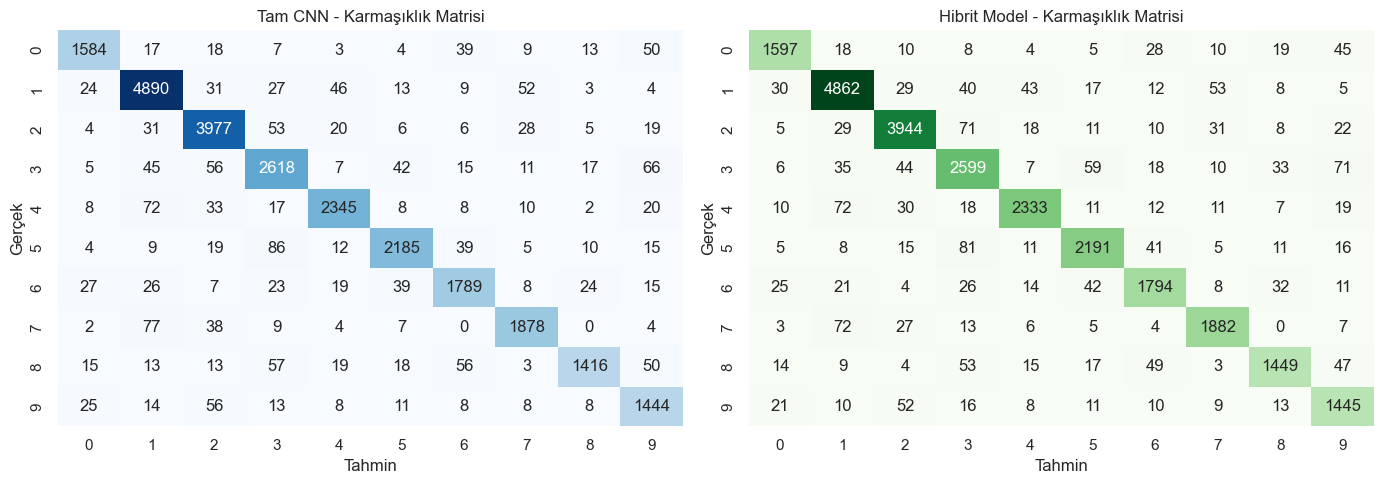

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Tam CNN - Karmaşıklık Matrisi')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

sns.heatmap(hybrid_cm, annot=True, fmt='d', cmap='Greens', cbar=False, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Hibrit Model - Karmaşıklık Matrisi')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hybrid_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()


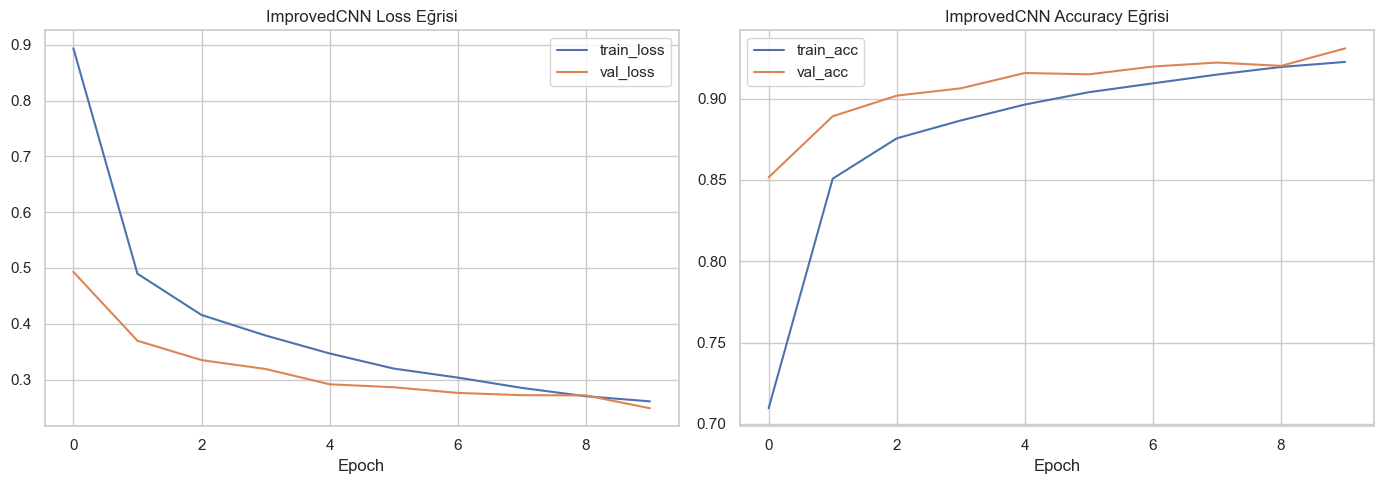

In [11]:
if cnn_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(cnn_history['train_loss'], label='train_loss')
    axes[0].plot(cnn_history['val_loss'], label='val_loss')
    axes[0].set_title('ImprovedCNN Loss Eğrisi')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(cnn_history['train_acc'], label='train_acc')
    axes[1].plot(cnn_history['val_acc'], label='val_acc')
    axes[1].set_title('ImprovedCNN Accuracy Eğrisi')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'hybrid_cnn_training_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Eğitim eğrileri gösterilmiyor çünkü model doğrudan checkpoint üzerinden yüklendi.')


## Sonuçların Raporlanması

Bu notebook çalıştırıldıktan sonra raporunda özellikle şu noktaları yazmalısın:
- CNN ile çıkarılan özelliklerin boyutu nedir?
- `.npy` dosyaları hangi amaçla üretildi?
- Hibrit model ile tam CNN arasındaki doğruluk farkı nedir?
- Hibrit modelin güçlü olduğu ve zayıf kaldığı sınıflar hangileridir?
- Özellik çıkarımının klasik makine öğrenmesi ile birleşmesi ne avantaj sağladı?

Rapor şablonu için bu klasördeki `README.md` dosyasını kullanabilirsin.


## Colab Çıktı İndirme

Bu hücre, `artifacts/` klasörünü `.zip` dosyasına dönüştürür. Böylece Colab runtime kapanmadan önce hibrit model sonuçlarını, `.npy` dosyalarını ve görselleri tek seferde indirebilirsin.


In [12]:
import shutil

archive_base = PROJECT_DIR / 'svhn_hibrit_artifacts'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=ARTIFACTS_DIR)
print(f'ZIP oluşturuldu: {archive_path}')

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print('Colab dışı ortam algılandı. ZIP dosyası belirtilen klasöre kaydedildi.')


ZIP oluşturuldu: d:\okul\3. sınıf yzm\Deep Learning\lab 2\proje2_cnn_odevi\svhn_hibrit_artifacts.zip
Colab dışı ortam algılandı. ZIP dosyası belirtilen klasöre kaydedildi.
